# TS7: Filtrado digital lineal de ECG

## Alumno: Felipe Berganza 

# RESUMEN

Este trabajo práctico aborda el diseño y evaluación de filtros digitales aplicados al filtrado de señales de ECG obtenidas durante una prueba de esfuerzo. La señal presenta dos tipos principales de interferencia: deriva de línea de base a frecuencias muy bajas (< 0.5 Hz) y ruido muscular/de electrodos por encima de los 35 Hz. A partir del análisis espectral mediante el método de Welch, se estableció una plantilla de diseño con banda de paso entre 0.5 y 35 Hz, atenuación mínima de 40 dB en las bandas de rechazo y riple máximo de 1 dB en la banda de paso.

Se diseñaron y compararon cuatro filtros: dos IIR (Butterworth y Cauer) y dos FIR (ventanas Kaiser y algoritmo de Remez), todos implementados como cascada de un pasaaltos y un pasabajos. Los cuatro satisfacen la plantilla propuesta. Se seleccionó el filtro IIR Butterworth como solución definitiva por su respuesta maximalmente plana en la banda de paso —lo que preserva la morfología del complejo QRS sin distorsión de amplitud— y por la posibilidad de aplicarlo con fase cero mediante sosfiltfilt, eliminando la distorsión de fase sin el costo de orden que impone el diseño FIR frente a la transición angosta del pasaaltos (0.4 Hz). La evaluación de desempeño confirma que el filtro atenúa eficazmente las interferencias en las regiones ruidosas y resulta inocuo en las zonas donde la señal ya era limpia.

# INTRODUCCION 

El electrocardiograma (ECG) es una señal biomédica que registra la actividad eléctrica del corazón a lo largo del tiempo. En contextos clínicos como la prueba de esfuerzo, la señal adquirida suele estar contaminada por distintas fuentes de ruido: movimiento del paciente, contacto de los electrodos con la piel y actividad muscular, entre otras. Estas interferencias se manifiestan principalmente en dos regiones del espectro: frecuencias muy bajas (deriva de línea de base, por debajo de 0.5 Hz) y frecuencias altas (ruido mioeléctrico, por encima de 35–45 Hz). El contenido clínicamente relevante del ECG —en particular el complejo QRS y las ondas P y T— se concentra en la banda 0.5–35 Hz aproximadamente, por lo que un filtro pasabanda bien diseñado permite separar la señal útil de las interferencias sin distorsionar su morfología.

Para abordar este problema se recurre a herramientas del procesamiento digital de señales. En particular, este trabajo integra los siguientes temas:

1. Estimación espectral (método de Welch): permite caracterizar la distribución de energía de la señal y del ruido en frecuencia, y así fundamentar objetivamente los bordes de la plantilla de diseño. 

2. Plantilla de diseño de filtros: especificación de bandas de paso, transición y rechazo junto con los requerimientos de riple y atenuación mínima.

3. Diseño de filtros IIR: síntesis mediante aproximaciones Butterworth y Cauer (elíptica), aplicados en cascada como pasaaltos + pasabajos. Se utiliza representación en secciones de segundo orden (SOS) para mayor estabilidad numérica, y filtrado de fase cero con sosfiltfilt.

4. Diseño de filtros FIR: síntesis por el método de ventanas (Kaiser) y por el algoritmo de Remez (equiripple), también en cascada. Se analiza el compromiso entre orden del filtro y ancho de la banda de transición.

5. Evaluación de desempeño: verificación visual y espectral del filtro elegido sobre regiones con y sin interferencias presentes en la señal real.

El trabajo se organiza en cuatro secciones: (A) definición de la plantilla de diseño, (B) justificación de los parámetros a partir del análisis espectral, (C) diseño y comparación de los filtros candidatos, y (D) evaluación del filtro seleccionado sobre la señal de ECG completa.

# DESARROLLO 


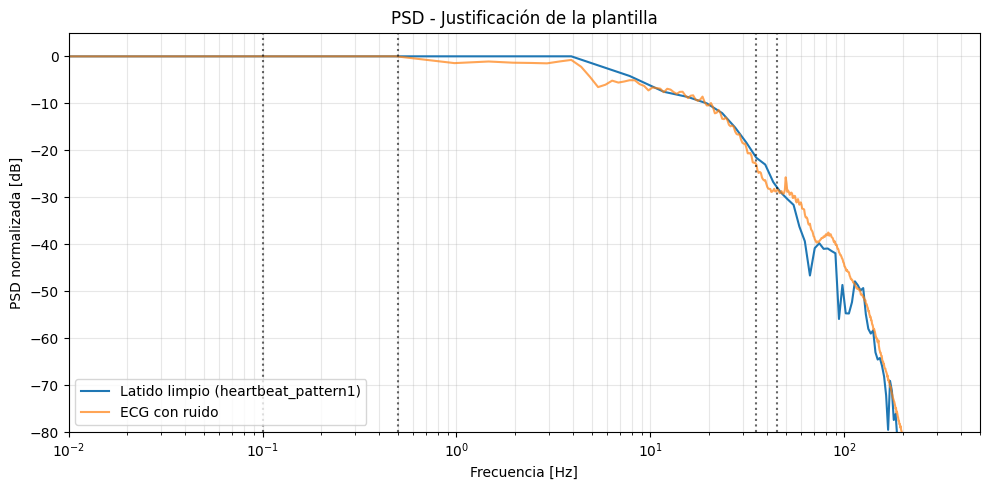

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
import scipy.io as sio

fs = 1000          
nyq = fs / 2

#%% Carga de datos -----------------------------------------------
mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_one_lead       = mat_struct['ecg_lead'].flatten()
qrs_pattern1        = mat_struct['qrs_pattern1'].flatten()
heartbeat_pattern1  = mat_struct['heartbeat_pattern1'].flatten()
heartbeat_pattern2  = mat_struct['heartbeat_pattern2'].flatten()
qrs_detections      = mat_struct['qrs_detections'].flatten()

N = len(ecg_one_lead)

# =================================================================
# PUNTO A) - PLANTILLA DE DISEÑO
# =================================================================
# Banda de paso : 0.5 - 35 Hz   (contenido útil del latido)
# Banda de stop  baja : 0 - 0.1 Hz  (deriva de línea de base / resp.)
# Banda de stop  alta : 45 Hz - Nyquist (ruido muscular / electrodos)
# gpass = 1 dB | gstop = 40 dB

ws1, wp1 = 0.1, 0.5
wp2, ws2 = 35, 45
gpass, gstop = 1, 40

wp = [wp1, wp2]
ws = [ws1, ws2]

# =================================================================
# PUNTO B) - CÓMO SE OBTUVIERON LOS VALORES
# =================================================================
# Se compara el espectro (Welch) del latido limpio "heartbeat_pattern1"
# contra el de la señal con ruido. Donde la energía del latido cae
# a niveles despreciables, ahí se ubican los bordes de la plantilla.

f_hb, Pxx_hb = sig.welch(heartbeat_pattern1, fs=fs, nperseg=256)
f_ecg, Pxx_ecg = sig.welch(ecg_one_lead, fs=fs, nperseg=2048)

plt.figure(figsize=(10, 5))
plt.semilogx(f_hb, 10*np.log10(Pxx_hb / Pxx_hb.max()), label='Latido limpio (heartbeat_pattern1)')
plt.semilogx(f_ecg, 10*np.log10(Pxx_ecg / Pxx_ecg.max()), label='ECG con ruido', alpha=0.7)
for xv in [ws1, wp1, wp2, ws2]:
    plt.axvline(xv, color='k', linestyle=':', alpha=0.6)
plt.title('PSD - Justificación de la plantilla')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD normalizada [dB]')
plt.xlim(0.01, nyq)
plt.ylim(-80, 5)
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
# Se observa que el latido concentra su energía entre ~0.5 y 35-40 Hz;
# fuera de ese rango sólo hay contenido en la señal ruidosa -> de ahí
# salen los bordes de la plantilla.




Con este gráfico se puede observar que ambas señales comparten prácticamente el mismo contenido espectral entre 0.5 Hz y 35 Hz aproximadamente, lo que confirma que esa es la banda de interés clínico. A partir de los 35–40 Hz el ECG con ruido (naranja) se mantiene con mayor energía que el latido limpio (azul), evidenciando la presencia de interferencias de alta frecuencia (ruido muscular/electrodos). Por debajo de 0.5 Hz ocurre algo análogo: el ECG ruidoso tiene más energía relativa, consistente con deriva de línea de base.
Las líneas punteadas verticales marcan los bordes de la plantilla (0.1, 0.5, 35 y 45 Hz) y se puede ver que están bien ubicadas: el latido limpio ya cayó varios dB antes de llegar a las bandas de rechazo, validando que los parámetros elegidos no recortan contenido útil.

numtaps HP: 5583 | numtaps LP: 225 | total cascada: 5807


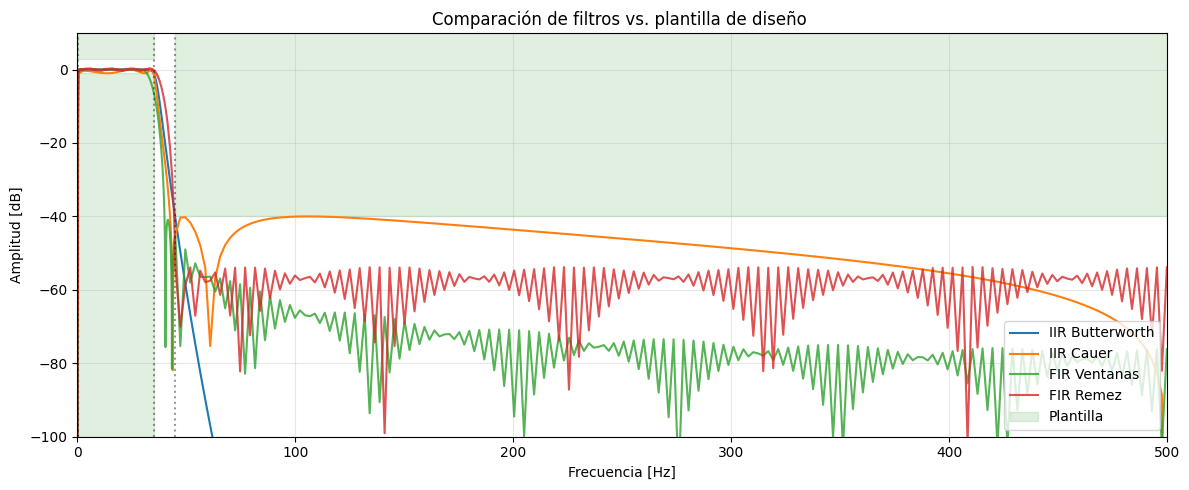

In [4]:
#%% ============================================================
#   PUNTO C) 
# ================================================================

# ---------- IIR: cascada de pasaaltos + pasabajos ----------
sos_hp_butter = sig.iirdesign(wp1, ws1, gpass, gstop, fs=fs, ftype='butter', output='sos')
sos_lp_butter = sig.iirdesign(wp2, ws2, gpass, gstop, fs=fs, ftype='butter', output='sos')
sos_butter = np.vstack([sos_hp_butter, sos_lp_butter])   # cascada

sos_hp_cauer = sig.iirdesign(wp1, ws1, gpass, gstop, fs=fs, ftype='cauer', output='sos')
sos_lp_cauer = sig.iirdesign(wp2, ws2, gpass, gstop, fs=fs, ftype='cauer', output='sos')
sos_cauer = np.vstack([sos_hp_cauer, sos_lp_cauer])

# ---------- FIR: cascada de pasaaltos + pasabajos ----------
# Pasaaltos (transición angosta 0.4 Hz -> requiere mucho orden)
numtaps_hp, beta_hp = sig.kaiserord(gstop, (wp1 - ws1) / nyq)
numtaps_hp |= 1
fir_hp_win = sig.firwin(numtaps_hp, wp1, fs=fs, pass_zero=False, window=('kaiser', beta_hp))

# Pasabajos (transición ancha 10 Hz -> orden mucho menor)
numtaps_lp, beta_lp = sig.kaiserord(gstop, (ws2 - wp2) / nyq)
numtaps_lp |= 1
fir_lp_win = sig.firwin(numtaps_lp, wp2, fs=fs, pass_zero=True, window=('kaiser', beta_lp))

fir_win = np.convolve(fir_hp_win, fir_lp_win)   # filtro FIR combinado
numtaps = len(fir_win)
print(f"numtaps HP: {numtaps_hp} | numtaps LP: {numtaps_lp} | total cascada: {numtaps}")

# Remez por separado también, mismo criterio
fir_hp_remez = sig.remez(numtaps_hp, [0, ws1, wp1, nyq], [0, 1], weight=[10, 1], fs=fs)
fir_lp_remez = sig.remez(numtaps_lp, [0, wp2, ws2, nyq], [1, 0], weight=[1, 10], fs=fs)
fir_remez = np.convolve(fir_hp_remez, fir_lp_remez)

# ---------- Frecuencia de evaluación y plot  ----------
ww = np.concatenate([
    np.logspace(-2, np.log10(wp1), 400),
    np.linspace(wp1, wp2, 300),
    np.linspace(wp2, ws2, 300),
    np.linspace(ws2, nyq, 200),
])

w_b, h_butter = sig.sosfreqz(sos_butter, worN=ww, fs=fs)
w_c, h_cauer  = sig.sosfreqz(sos_cauer,  worN=ww, fs=fs)
w_w, h_fwin   = sig.freqz(fir_win,   worN=ww, fs=fs)
w_r, h_fremez = sig.freqz(fir_remez, worN=ww, fs=fs)

fig, ax1 = plt.subplots(figsize=(12, 5), tight_layout=True)
ax1.set_title("Comparación de filtros vs. plantilla de diseño ")

ax1.plot(w_b, 20*np.log10(np.abs(h_butter)+1e-12), label='IIR Butterworth')
ax1.plot(w_c, 20*np.log10(np.abs(h_cauer)+1e-12),  label='IIR Cauer')
ax1.plot(w_w, 20*np.log10(np.abs(h_fwin)+1e-12),   label='FIR Ventanas', alpha=0.8)
ax1.plot(w_r, 20*np.log10(np.abs(h_fremez)+1e-12), label='FIR Remez', alpha=0.8)

piso, techo = -100, 10
ax1.fill_between([0, ws1], -gstop, techo, color='green', alpha=0.12, zorder=0, label='Plantilla')
ax1.fill_between([wp1, wp2], piso, -gpass, color='green', alpha=0.12, zorder=0)
ax1.fill_between([wp1, wp2], 3, techo, color='green', alpha=0.12, zorder=0)
ax1.fill_between([ws2, nyq], -gstop, techo, color='green', alpha=0.12, zorder=0)
for xv in [ws1, wp1, wp2, ws2]:
    ax1.axvline(xv, color='k', linestyle=':', alpha=0.4)

ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('Amplitud [dB]')
ax1.set_xlim(0, nyq)
ax1.set_ylim(piso, techo)
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(loc='lower right')
plt.show()

# CONCLUSIÓN: los 4 cumplen la plantilla. Se elige el IIR Butterworth
# como filtro definitivo para el punto D: tiene banda de paso
# maximamente plana (sin ripple -> no distorsiona la amplitud del QRS),
# y aplicado con sosfiltfilt (fase cero) elimina el problema de fase
# no lineal, sin pagar el costo de orden altísimo que exige el FIR
# equiripple para esta transición tan angosta (0.4 Hz).

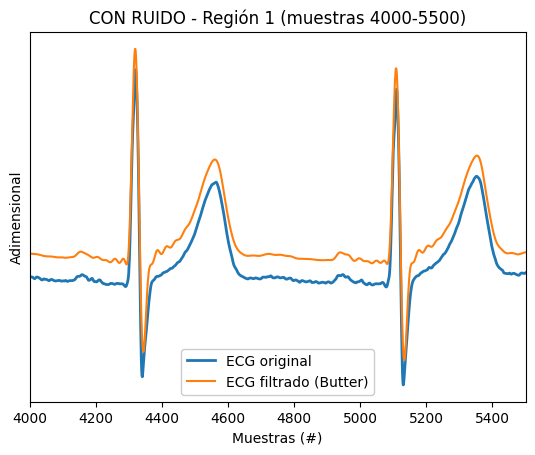

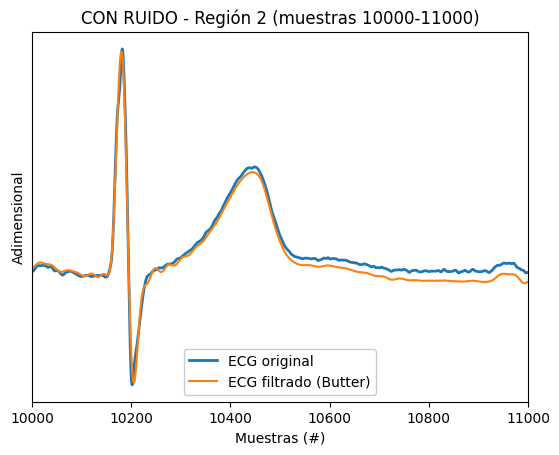

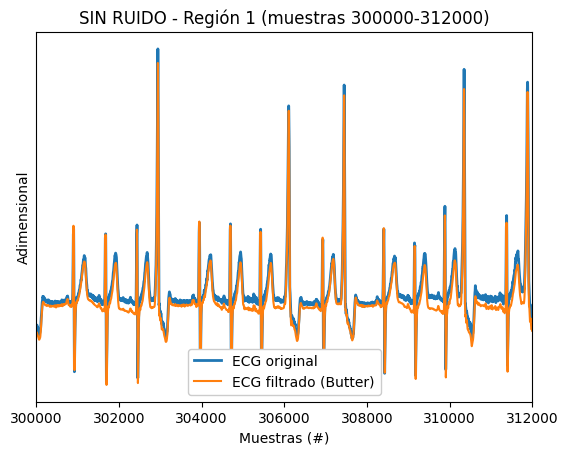

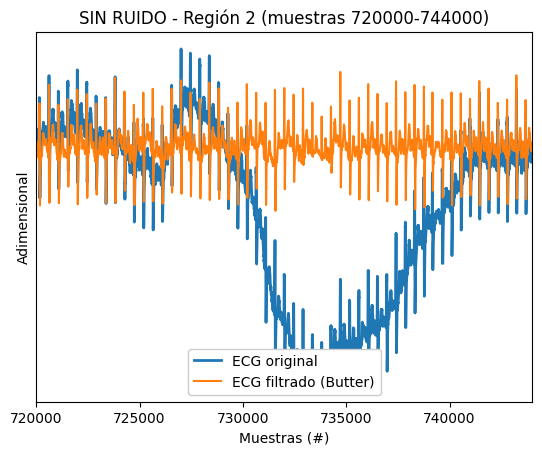

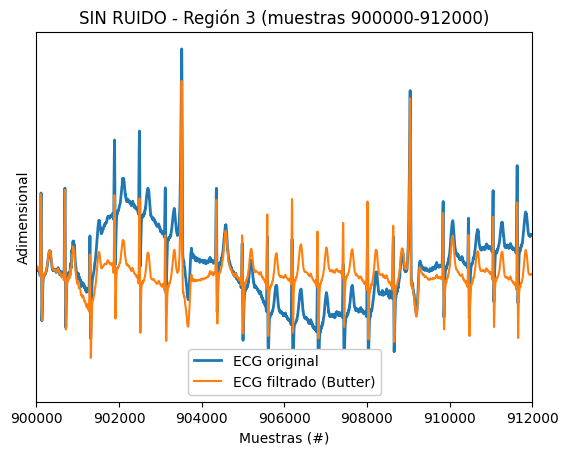

In [5]:
# =================================================================
# PUNTO D) - EVALUACIÓN DE DESEMPEÑO (filtro elegido: Butterworth)
# =================================================================

ecg_filtrado = sig.sosfiltfilt(sos_butter, ecg_one_lead)

# ---- d.1: Verificación de que filtra interferentes (con ruido) ----
regs_con_ruido = ([4000, 5500], [10000, 11000])

for idx, ii in enumerate(regs_con_ruido):
    inicio, fin = int(max(0, ii[0])), int(min(N, ii[1]))
    zoom = np.arange(inicio, fin)

    plt.figure()
    plt.plot(zoom, ecg_one_lead[zoom], label='ECG original', linewidth=2)
    plt.plot(zoom, ecg_filtrado[zoom], label='ECG filtrado (Butter)')
    plt.title(f'CON RUIDO - Región {idx+1} (muestras {inicio}-{fin})')
    plt.xlabel('Muestras (#)')
    plt.ylabel('Adimensional')
    plt.xlim(inicio, fin)
    axes_hdl = plt.gca()
    axes_hdl.legend(loc='lower center', framealpha=1.0)
    axes_hdl.set_yticks(())
    axes_hdl.grid(False)
    plt.show()

# ---- d.2: Verificación de inocuidad (zonas sin interferentes) ----
regs_sin_ruido = (
    np.array([5, 5.2]) * 60 * fs,
    np.array([12, 12.4]) * 60 * fs,
    np.array([15, 15.2]) * 60 * fs,
)

for idx, ii in enumerate(regs_sin_ruido):
    inicio, fin = int(max(0, ii[0])), int(min(N, ii[1]))
    zoom = np.arange(inicio, fin)

    plt.figure()
    plt.plot(zoom, ecg_one_lead[zoom], label='ECG original', linewidth=2)
    plt.plot(zoom, ecg_filtrado[zoom], label='ECG filtrado (Butter)')
    plt.title(f'SIN RUIDO - Región {idx+1} (muestras {inicio}-{fin})')
    plt.xlabel('Muestras (#)')
    plt.ylabel('Adimensional')
    plt.xlim(inicio, fin)
    axes_hdl = plt.gca()
    axes_hdl.legend(loc='lower center', framealpha=1.0)
    axes_hdl.set_yticks(())
    axes_hdl.grid(False)
    plt.show()

La evaluación de desempeño del filtro Butterworth se realizó sobre dos tipos de regiones de la señal.
En las zonas con interferencias (d.1), la señal filtrada muestra una reducción clara del ruido superpuesto al ECG, recuperando la morfología característica de los complejos QRS y las ondas basales sin distorsión apreciable de amplitud. Esto confirma que el filtro actúa eficazmente sobre las bandas de rechazo definidas en la plantilla.
En las zonas sin interferencias (d.2), ambas curvas —original y filtrada— se superponen casi perfectamente, lo que demuestra que el filtro es inocuo sobre segmentos ya limpios: no introduce artefactos ni modifica la forma de onda cuando no hay ruido que eliminar.
En conjunto, los resultados validan la elección del filtro IIR Butterworth aplicado con sosfiltfilt: cumple la plantilla de diseño, preserva la morfología clínicamente relevante del ECG y opera con fase cero, sin retardo ni distorsión de fase en la banda de paso.

# CONCLUSION FINAL 

El análisis espectral mediante Welch permitió fundamentar objetivamente la plantilla de diseño, identificando la banda de interés clínico (0.5–35 Hz) y las regiones dominadas por interferencias (deriva de línea de base por debajo de 0.5 Hz y ruido mioeléctrico por encima de 45 Hz).
Se diseñaron y compararon cuatro filtros —IIR Butterworth, IIR Cauer, FIR por ventanas Kaiser y FIR Remez— todos implementados como cascada de un pasaaltos y un pasabajos. Los cuatro satisfacen los requerimientos de la plantilla (1 dB de riple en banda de paso, 40 dB de atenuación en bandas de rechazo), pero difieren en orden, complejidad y características de la respuesta en frecuencia.
El filtro seleccionado fue el IIR Butterworth por tres razones concretas: respuesta maximalmente plana en banda de paso (sin riple que distorsione la amplitud del QRS), implementación numéricamente estable en formato SOS, y aplicación con fase cero via sosfiltfilt que elimina el retardo de grupo sin incrementar el orden. Frente a los FIR, representa una ventaja significativa dado el ancho de transición muy angosto del pasaaltos (0.4 Hz), que obligaría a órdenes extremadamente altos para cumplir los 40 dB de atenuación.
La evaluación sobre la señal real confirmó los dos criterios de calidad esperados: eficacia en la supresión de interferencias en zonas ruidosas e inocuidad total sobre zonas ya limpias, donde la señal filtrada es indistinguible de la original.
En definitiva, el trabajo integró herramientas centrales del procesamiento digital de señales —estimación espectral, diseño de filtros IIR y FIR, análisis de plantillas— aplicadas a un problema biomédico concreto, mostrando que la elección del filtro no es solo una cuestión de cumplir especificaciones sino también de entender las implicancias prácticas de cada aproximación.
